# Project 1 — LendingClub Interest Rate Prediction
**OPAN 6604 Applied AI · Step 1: EDA + Preprocessing**

This notebook covers the first step of Project 1: explore the LendingClub data,
make defensible feature-selection decisions, and produce a clean modeling-ready
dataset. Modeling, tuning, explainability, and the final test-set prediction
are handled in follow-on notebooks.

**Target:** `int_rate` (loan interest rate, continuous).

**Stance on leakage:** we model from the lender's perspective at *underwriting
time*. Any feature that reflects post-funding borrower behavior, or whose
snapshot date is unclear, is dropped. This trades some raw predictive power
for a model whose feature use we can defend in business terms.

> **AI-tool citation (per course policy):** Claude (Anthropic) was used as a
> coding assistant for the structure of this notebook and to surface candidate
> leakage columns. All decisions, interpretations, and final code were reviewed
> and approved by the student author.

## 1. Setup

In [3]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42
DATA_DIR = Path.cwd()              # notebook lives in Project 1/
ARTIFACTS_DIR = DATA_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)
print("data dir:", DATA_DIR)
print("artifacts dir:", ARTIFACTS_DIR)

data dir: c:\Users\mattd\Desktop\School\Mod 5\AI Modeling in Practice\Project 1\Update
artifacts dir: c:\Users\mattd\Desktop\School\Mod 5\AI Modeling in Practice\Project 1\Update\artifacts


## 2. Load

Read both CSVs as-is. Verify the test set has every column the train set has
(minus `int_rate`) plus the `ID` column we need to preserve for the submission
later. Stash the test IDs so they survive the cleaning pipeline.

In [4]:
#Optional file path direction to access from Google Drive - can delete if you want (MD 5/26)
#from google.colab import drive
#drive.mount('/content/drive')
#Add shortcut to folder in Shared Drive to 'My Drive' for the step below
#DATA_DIR = Path('/content/drive/MyDrive/Predictive Analytics')
#train_raw = pd.read_csv(DATA_DIR / 'LC_train.csv')
#test_raw = pd.read_csv(DATA_DIR / 'LC_test.csv')

In [5]:
train_raw = pd.read_csv(DATA_DIR / "LC_train.csv")
test_raw = pd.read_csv(DATA_DIR / "LC_test.csv")

print(f"train_raw: {train_raw.shape}")
print(f"test_raw : {test_raw.shape}")

# Confirm structure
assert "int_rate" in train_raw.columns, "missing target in train"
assert "ID" in test_raw.columns, "missing ID in test"
extra_in_test = set(test_raw.columns) - set(train_raw.columns)
extra_in_train = set(train_raw.columns) - set(test_raw.columns)
print(f"in test only: {extra_in_test}")
print(f"in train only: {extra_in_train}")

# Preserve test IDs and drop from features
test_ids = test_raw["ID"].copy()
test_raw = test_raw.drop(columns=["ID"])

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\mattd\\Desktop\\School\\Mod 5\\AI Modeling in Practice\\Project 1\\Update\\LC_train.csv'

## 3. Initial EDA (pre-cleaning)

Three diagnostics motivate the column-dropping that follows:

1. **Target distribution** — what we're trying to predict.
2. **Missingness profile** — which columns are too sparse to be useful.
3. **Dtype table** — which columns are objects (need encoding) vs numeric.

count    100000.000
mean         12.947
std           5.256
min           6.460
25%           8.190
50%          11.710
75%          16.120
max          30.990
Name: int_rate, dtype: float64


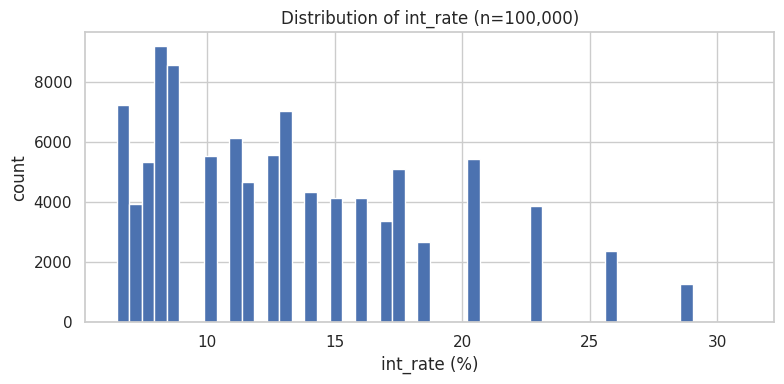

In [ ]:
# Target distribution
y_raw = train_raw["int_rate"]
print(y_raw.describe().round(3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_raw, bins=50, edgecolor="white")
ax.set_xlabel("int_rate (%)")
ax.set_ylabel("count")
ax.set_title(f"Distribution of int_rate (n={len(y_raw):,})")
plt.tight_layout()
plt.show()

10 columns have any missingness
mths_since_last_record    90.88
emp_title                 14.92
mths_since_recent_inq      9.98
emp_length                 8.67
mths_since_rcnt_il         2.20
mo_sin_old_il_acct         2.20
mths_since_recent_bc       0.92
dti                        0.19
revol_util                 0.12
all_util                   0.02


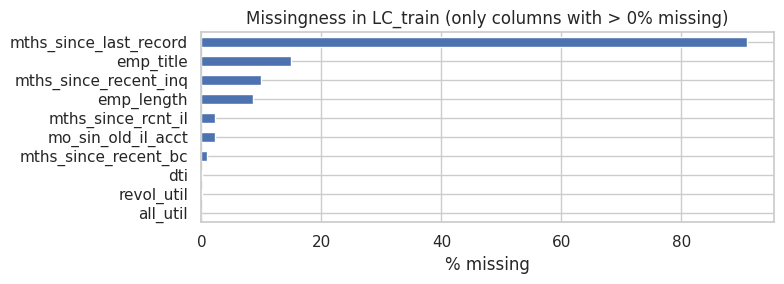

In [ ]:
# Missingness
miss = (train_raw.isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]
print(f"{len(miss)} columns have any missingness")
print(miss.round(2).to_string())

fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * len(miss))))
miss.plot.barh(ax=ax)
ax.set_xlabel("% missing")
ax.set_title("Missingness in LC_train (only columns with > 0% missing)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Dtype + cardinality table
def dtype_profile(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for c in df.columns:
        s = df[c]
        rows.append({
            "column": c,
            "dtype": str(s.dtype),
            "n_unique": s.nunique(dropna=True),
            "pct_missing": round(s.isna().mean() * 100, 2),
        })
    return pd.DataFrame(rows).set_index("column")

dtype_profile(train_raw)

,dtype,n_unique,pct_missing
column,,,
addr_state,object,50,0.00
all_util,float64,151,0.02
annual_inc,float64,9082,0.00
application_type,object,2,0.00
chargeoff_within_12_mths,int64,6,0.00
collections_12_mths_ex_med,int64,6,0.00
delinq_2yrs,int64,18,0.00
dti,float64,6332,0.19
emp_length,object,11,8.67


## 4. Column drops — feature selection with a leakage lens

We drop 17 of 38 features in three groups. The reasoning for each is the
key intellectual contribution of this preprocessing step; the rest is mechanics.

**POST (3 cols, direct leakage)** — only observable *after* the loan is funded:

- `loan_status` — current paid/default state.
- `chargeoff_within_12_mths` — whether the loan was charged off in the year
  following origination.
- `collections_12_mths_ex_med` — collections activity in the 12 months
  following origination.

**AMBIG (10 cols, current-snapshot drift)** — the LendingClub dataset is a
snapshot taken at an unknown date *after* loans were issued, so "current
balance" and "current utilization" fields reflect post-funding borrower
behavior rather than the state at underwriting:

- Balance / utilization: `all_util`, `revol_bal`, `revol_util`, `tot_cur_bal`,
  `total_bal_ex_mort`, `tot_coll_amt`.
- Recency-of-activity: `inq_last_12m`, `mths_since_recent_inq`,
  `mths_since_recent_bc`, `mths_since_rcnt_il`.

**Low-value / redundant (4 cols)** — either too sparse, too messy, or
duplicated by another feature:

- `mths_since_last_record` — 91% missing; the at-application signal is already
  carried by `pub_rec` and `pub_rec_bankruptcies`.
- `emp_title` — 35K unique free-text strings; would need real NLP work for a
  marginal lift over `emp_length`.
- `title` — perfect duplicate of `purpose` (same 11 categories).
- `zip_code` — 873 unique values, redundant with `addr_state` without
  geocoding to demographic features.

This leaves **21 features**: 7 numeric continuous, 7 numeric counts, 6
low-cardinality categoricals, and 1 high-cardinality categorical (`addr_state`,
50 levels).

In [ ]:
POST_COLS = [
    "loan_status",
    "chargeoff_within_12_mths",
    "collections_12_mths_ex_med",
]
AMBIG_COLS = [
    "all_util", "revol_bal", "revol_util",
    "tot_cur_bal", "total_bal_ex_mort", "tot_coll_amt",
    "inq_last_12m", "mths_since_recent_inq",
    "mths_since_recent_bc", "mths_since_rcnt_il",
]
LOW_VALUE_COLS = [
    "mths_since_last_record", "emp_title", "title", "zip_code",
]
DROP_COLS = POST_COLS + AMBIG_COLS + LOW_VALUE_COLS
assert len(DROP_COLS) == 17

train = train_raw.drop(columns=DROP_COLS)
test = test_raw.drop(columns=DROP_COLS)
print(f"train after drops: {train.shape}  (22 = 21 features + int_rate)")
print(f"test  after drops: {test.shape}   (21 features)")

train after drops: (100000, 22)  (22 = 21 features + int_rate)
test  after drops: (10000, 21)   (21 features)


## 5. String cleanup

Two object-typed columns encode numbers as strings:

- `term` — `' 36 months'` / `' 60 months'` (note the leading space).
- `emp_length` — `'< 1 year'`, `'1 year'`, …, `'10+ years'` (ordinal).

Map both to integers so they can feed the numeric branch of the preprocessor.
Missing employment lengths stay as NaN and get imputed in the pipeline.

In [ ]:
def clean_term(s):
    if pd.isna(s):
        return np.nan
    # ' 36 months' -> 36
    return int(str(s).strip().split()[0])

EMP_MAP = {
    "< 1 year": 0,
    "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4, "5 years": 5,
    "6 years": 6, "7 years": 7, "8 years": 8, "9 years": 9,
    "10+ years": 10,
}
def clean_emp_length(s):
    if pd.isna(s):
        return np.nan
    return EMP_MAP.get(str(s).strip(), np.nan)

for df in (train, test):
    df["term"] = df["term"].apply(clean_term).astype("Int64")
    df["emp_length"] = df["emp_length"].apply(clean_emp_length).astype("float64")

print("term values  :", sorted(train["term"].dropna().unique()))
print("emp_length   :", sorted(train["emp_length"].dropna().unique()))

term values  : [np.int64(36), np.int64(60)]
emp_length   : [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0)]


## 6. Minimal feature engineering

Add `fico_score` as the midpoint of `fico_range_high` and `fico_range_low`.
We *keep both originals* for now — gradient-boosted trees are robust to the
redundancy, and dropping a component is a modeling-time decision better made
once we see feature importance.

In [ ]:
for df in (train, test):
    df["fico_score"] = (df["fico_range_high"] + df["fico_range_low"]) / 2

print(train[["fico_range_low", "fico_range_high", "fico_score"]].describe().round(1))

       fico_range_low  fico_range_high  fico_score
count        100000.0         100000.0    100000.0
mean            706.6            710.6       708.6
std              35.6             35.6        35.6
min             660.0            664.0       662.0
25%             680.0            684.0       682.0
50%             700.0            704.0       702.0
75%             725.0            729.0       727.0
max             845.0            850.0       847.5


## 7. Outlier removal (training only)

Two columns have values that are almost certainly data-entry errors:

- `annual_inc` max is **$8.6M** vs a median of $73K.
- `dti` max is **999** vs a typical range of 0–60.

Drop training rows where `dti > 100` or `annual_inc > 1,000,000`. We do **not**
modify the test set — we must produce a prediction for every loan in `LC_test`,
extreme or not.

In [ ]:
before = len(train)
train = train[(train["dti"] <= 100) & (train["annual_inc"] <= 1_000_000)].reset_index(drop=True)
after = len(train)
print(f"outlier removal: {before:,} -> {after:,} "
      f"({before-after:,} dropped, {(before-after)/before:.2%})")

outlier removal: 100,000 -> 99,363 (637 dropped, 0.64%)


## 8. Train / holdout split

Split `LC_train` 80/20 with a fixed seed. The 80% feeds 5-fold CV during
hyperparameter tuning in the next step; the 20% is touched **once** at the
end to report an unbiased final score. The submission to LC_test is produced
by refitting on the full 100%.

In [ ]:
y = train["int_rate"]
X = train.drop(columns=["int_rate"])

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.20, random_state=SEED, shuffle=True
)
print(f"X_train  : {X_train.shape}, y_train  : {y_train.shape}")
print(f"X_holdout: {X_holdout.shape}, y_holdout: {y_holdout.shape}")
print(f"X_test   : {test.shape}")

X_train  : (79490, 22), y_train  : (79490,)
X_holdout: (19873, 22), y_holdout: (19873,)
X_test   : (10000, 22)


## 9. Bivariate EDA

Six focused views, each with a one-line business read. The goal is to confirm
that the kept features actually relate to `int_rate` in plausible ways — if
FICO doesn't drive rate in this data, something is wrong upstream.

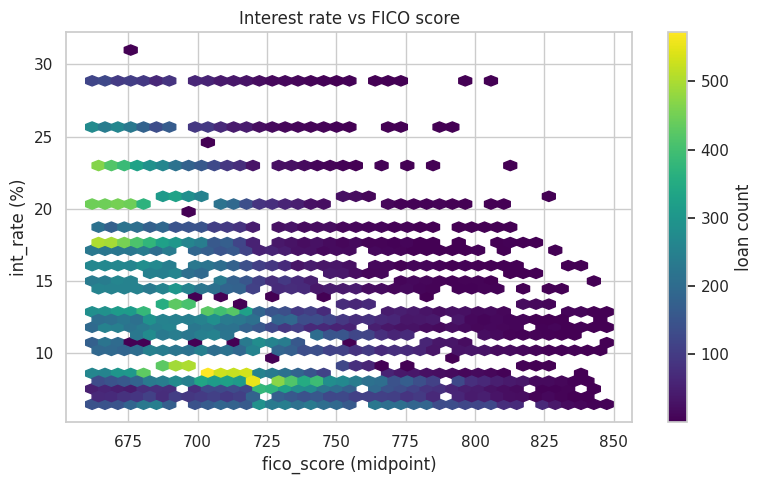

In [ ]:
# 9.1 FICO vs int_rate
fig, ax = plt.subplots(figsize=(8, 5))
hb = ax.hexbin(X_train["fico_score"], y_train, gridsize=40, cmap="viridis", mincnt=1)
fig.colorbar(hb, ax=ax, label="loan count")
ax.set_xlabel("fico_score (midpoint)")
ax.set_ylabel("int_rate (%)")
ax.set_title("Interest rate vs FICO score")
plt.tight_layout()
plt.show()

**Read:** clear negative relationship — higher FICO ⇒ lower rate. The
spread is wide at any given FICO, which tells us FICO alone won't be enough;
term, purpose, and DTI should carry additional signal.

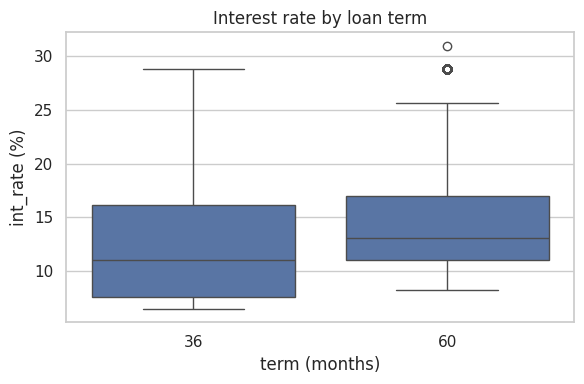

In [ ]:
# 9.2 Term vs int_rate
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x=X_train["term"], y=y_train, ax=ax)
ax.set_xlabel("term (months)")
ax.set_ylabel("int_rate (%)")
ax.set_title("Interest rate by loan term")
plt.tight_layout()
plt.show()

**Read:** 60-month loans price materially higher than 36-month loans —
consistent with longer-term credit being riskier from the lender's side.
`term` should be a high-importance feature.

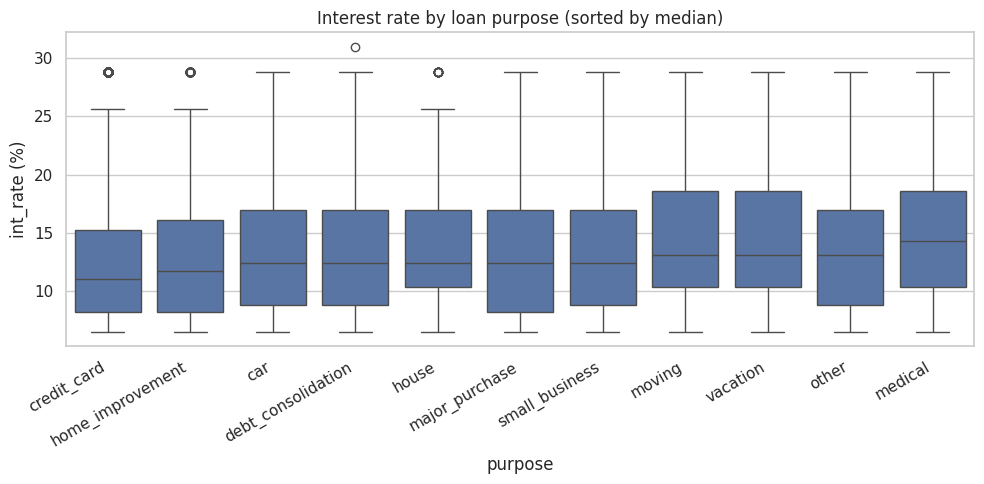

In [ ]:
# 9.3 Purpose vs int_rate
order = X_train.assign(int_rate=y_train).groupby("purpose")["int_rate"].median().sort_values().index
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(x=X_train["purpose"], y=y_train, order=order, ax=ax)
ax.set_xlabel("purpose")
ax.set_ylabel("int_rate (%)")
ax.set_title("Interest rate by loan purpose (sorted by median)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Read:** purpose matters but the spread within each category is large.
Lowest-rate categories tend to be secured-adjacent (e.g., home improvement,
car); highest tend to be discretionary or distress (small business, moving).

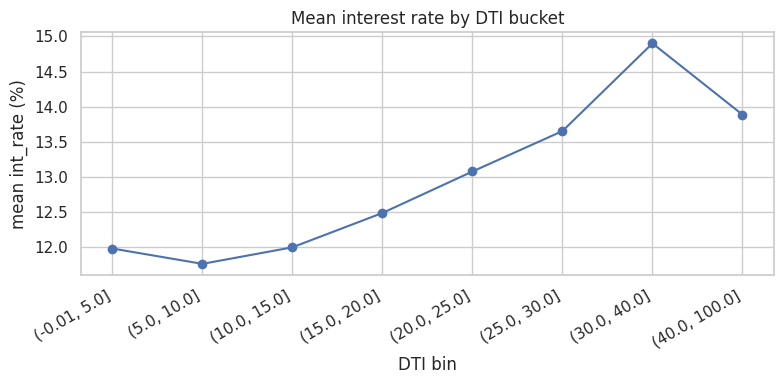

                    mean  count
dti_bin                        
(-0.01, 5.0]   11.982822   2821
(5.0, 10.0]    11.764576   8140
(10.0, 15.0]   12.000012  13815
(15.0, 20.0]   12.488771  15731
(20.0, 25.0]   13.078705  14460
(25.0, 30.0]   13.654020  11081
(30.0, 40.0]   14.901713  11059
(40.0, 100.0]  13.887037   2383


In [ ]:
# 9.4 DTI vs int_rate (binned)
bins = pd.cut(X_train["dti"], bins=[-0.01, 5, 10, 15, 20, 25, 30, 40, 100])
binned = pd.DataFrame({"dti_bin": bins, "int_rate": y_train.values}).groupby("dti_bin", observed=True)["int_rate"].agg(["mean", "count"])
fig, ax = plt.subplots(figsize=(8, 4))
binned["mean"].plot(marker="o", ax=ax)
ax.set_xlabel("DTI bin")
ax.set_ylabel("mean int_rate (%)")
ax.set_title("Mean interest rate by DTI bucket")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
print(binned)

**Read:** monotone increase in rate as DTI rises, with the steepest jump
above DTI = 25. DTI is doing real work even after controlling for FICO.

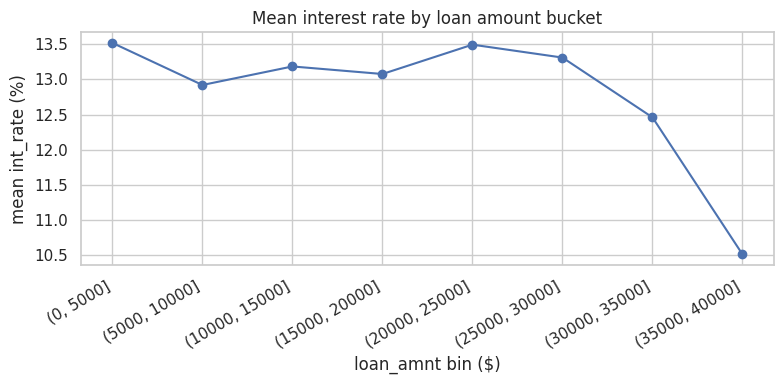

In [ ]:
# 9.5 Loan amount vs int_rate (binned)
amt_bins = pd.cut(X_train["loan_amnt"], bins=[0, 5000, 10000, 15000, 20000, 25000, 30000, 35000, 40000])
binned = pd.DataFrame({"amt_bin": amt_bins, "int_rate": y_train.values}).groupby("amt_bin", observed=True)["int_rate"].agg(["mean", "count"])
fig, ax = plt.subplots(figsize=(8, 4))
binned["mean"].plot(marker="o", ax=ax)
ax.set_xlabel("loan_amnt bin ($)")
ax.set_ylabel("mean int_rate (%)")
ax.set_title("Mean interest rate by loan amount bucket")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Read:** modest positive relationship — bigger loans price slightly
higher on average, though the effect is small compared with FICO or term.
Likely confounded with term (large loans more often use the 60-month product).

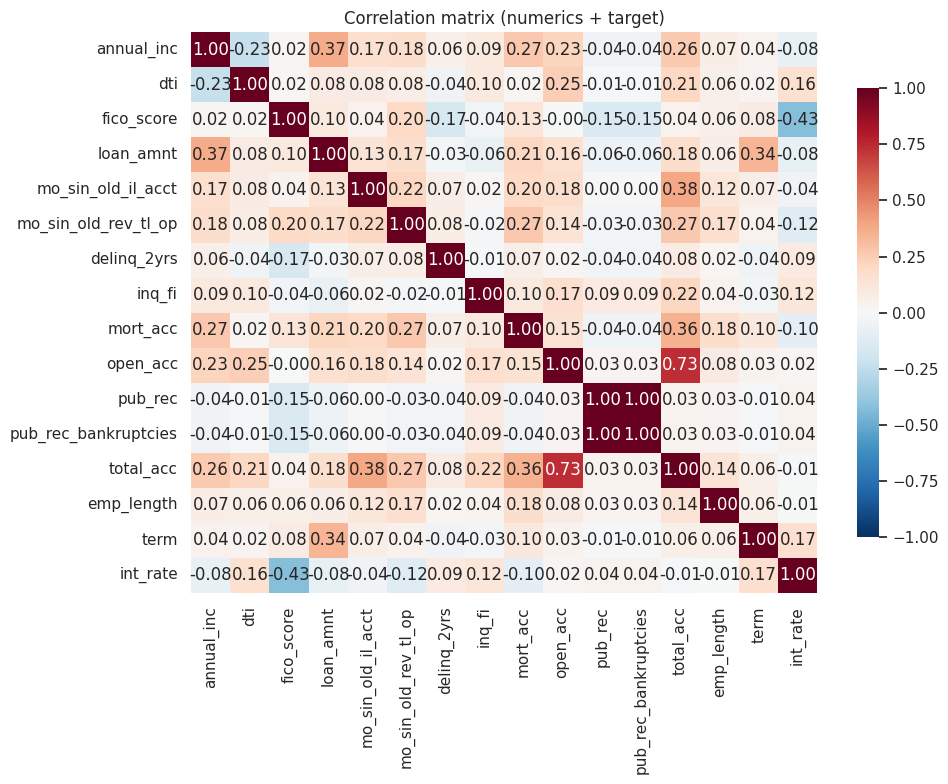

In [ ]:
# 9.6 Correlation heatmap on numeric features + target
numeric_for_corr = [
    "annual_inc", "dti", "fico_score", "loan_amnt",
    "mo_sin_old_il_acct", "mo_sin_old_rev_tl_op",
    "delinq_2yrs", "inq_fi", "mort_acc", "open_acc",
    "pub_rec", "pub_rec_bankruptcies", "total_acc",
    "emp_length", "term",
]
corr = X_train[numeric_for_corr].assign(int_rate=y_train.values).corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation matrix (numerics + target)")
plt.tight_layout()
plt.show()

**Read:** strongest correlations with `int_rate` are `term` (+) and
`fico_score` (−), exactly as expected. No two predictors are alarmingly
collinear except the FICO components (which we'll let the modeling step
collapse if needed). Most credit-history counts have small individual
correlations but may still matter inside a tree model.

## 10. Preprocessing pipeline

Wrap everything past row-level cleaning in a `ColumnTransformer` so the
modeling step can compose it with an estimator under cross-validation without
leakage. Numeric columns get median imputation + standard scaling (matters for
linear models, harmless for trees). Categoricals get most-frequent imputation
+ one-hot encoding with unknown categories ignored — that way an unseen
`addr_state` in the test set won't break inference.

In [ ]:
NUMERIC_COLS = [
    # continuous
    "annual_inc", "dti", "fico_range_high", "fico_range_low", "fico_score",
    "loan_amnt", "mo_sin_old_il_acct", "mo_sin_old_rev_tl_op",
    # count / ordinal
    "delinq_2yrs", "inq_fi", "mort_acc", "open_acc",
    "pub_rec", "pub_rec_bankruptcies", "total_acc",
    "emp_length", "term",
]
CATEGORICAL_COLS = [
    "application_type", "home_ownership", "purpose",
    "verification_status", "addr_state",
]

# Sanity: every feature column is accounted for, no overlap, no leftovers
assigned = set(NUMERIC_COLS) | set(CATEGORICAL_COLS)
assert assigned == set(X_train.columns), (
    f"unassigned: {set(X_train.columns) - assigned}, "
    f"extra: {assigned - set(X_train.columns)}"
)

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, NUMERIC_COLS),
    ("cat", categorical_pipe, CATEGORICAL_COLS),
])
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['annual_inc', 'dti', 'fico_range_high',
                                  'fico_range_low', 'fico_score', 'loan_amnt',
                                  'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op',
                                  'delinq_2yrs', 'inq_fi', 'mort_acc',
                                  'open_acc', 'pub_rec', 'pub_rec_bankruptcies',
                                  'total_acc', 'emp_length', 'term']),
                                ('cat',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ohe',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['application_type', 'home_ownership',
                                  'purpose', 'verification_status',
                                  'addr_state'])])

## 11. Fit + transform sanity check

Fit on the training fold only. Transform the holdout and test sets with the
same fitted preprocessor. Confirm shapes are consistent, no NaNs survive, and
no dropped column accidentally reappears in the final feature list.

In [ ]:
X_train_pp = preprocessor.fit_transform(X_train)
X_holdout_pp = preprocessor.transform(X_holdout)
X_test_pp = preprocessor.transform(test)

print(f"X_train_pp  : {X_train_pp.shape}")
print(f"X_holdout_pp: {X_holdout_pp.shape}")
print(f"X_test_pp   : {X_test_pp.shape}")

assert not np.isnan(X_train_pp).any(), "NaNs in X_train_pp"
assert not np.isnan(X_holdout_pp).any(), "NaNs in X_holdout_pp"
assert not np.isnan(X_test_pp).any(), "NaNs in X_test_pp"
assert X_train_pp.shape[1] == X_holdout_pp.shape[1] == X_test_pp.shape[1]

feature_names = preprocessor.get_feature_names_out()
print(f"final feature count: {len(feature_names)}")

# Leakage grep: no dropped column may survive as a feature name
for bad in DROP_COLS:
    survivors = [f for f in feature_names if bad in f]
    assert not survivors, f"leakage: {bad} survived as {survivors}"
print("leakage check passed")

X_train_pp  : (79490, 83)
X_holdout_pp: (19873, 83)
X_test_pp   : (10000, 83)
final feature count: 83
leakage check passed


## 12. Persist artifacts

Save the fitted preprocessor and the three transformed matrices (plus
targets, test IDs, feature names, and column lists) so the modeling notebook
can start from clean inputs without re-running this pipeline.

In [ ]:
joblib.dump(preprocessor, ARTIFACTS_DIR / "preprocessor.joblib")
joblib.dump(
    {
        "X_train": X_train_pp,
        "y_train": y_train.to_numpy(),
        "X_holdout": X_holdout_pp,
        "y_holdout": y_holdout.to_numpy(),
        "X_test": X_test_pp,
        "test_ids": test_ids.to_numpy(),
        "feature_names": feature_names,
        "numeric_cols": NUMERIC_COLS,
        "categorical_cols": CATEGORICAL_COLS,
    },
    ARTIFACTS_DIR / "modeling_arrays.joblib",
)

# Round-trip check
loaded = joblib.load(ARTIFACTS_DIR / "preprocessor.joblib")
assert np.allclose(loaded.transform(X_holdout), X_holdout_pp)
print("artifacts written to:", ARTIFACTS_DIR)
print("joblib round-trip OK")

artifacts written to: /content/artifacts
joblib round-trip OK


## 13. Summary & next step

**What we did**

- Dropped 17 of 38 features in three documented groups: 3 direct post-funding
  leaks, 10 ambiguous "current snapshot" fields, and 4 low-value / redundant
  columns. Net: 21 raw features, becoming 83 features after one-hot encoding.
- Cleaned the two string-encoded numeric columns (`term`, `emp_length`).
- Added `fico_score` as the FICO range midpoint.
- Dropped ~0.64% of training rows as obvious data-entry outliers (`dti > 100`
  or `annual_inc > $1M`). Left the test set untouched — we must predict on
  every loan in `LC_test`.
- Split 80/20 with `random_state=42`; the 20% holdout stays untouched until
  final model evaluation.
- Built a `ColumnTransformer` pipeline (median + scale for numerics,
  most-frequent + one-hot for categoricals) and persisted both the fitted
  pipeline and the transformed matrices under `artifacts/`.

**What's next**

In the modeling notebook we'll load `artifacts/modeling_arrays.joblib`, train
at least two regressors (planned: a regularized linear baseline and a
gradient-boosted tree), tune them with 5-fold CV on `X_train`, score the
winner once on `X_holdout`, refit on the union of the two, and produce the
`LC_test` submission CSV using `test_ids`.

> **AI-tool citation reminder:** Claude (Anthropic) assisted with notebook
> structure and the initial leakage-classification triage. All preprocessing
> decisions documented above were reviewed and chosen by the student author.

---
# Step 2: Baseline + XGBoost Tuning (Grid + Random Search)
---

## 1. Setup

Imports, paths, and a fixed random seed (matches step 1).

In [1]:
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import loguniform, randint, uniform
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    RandomizedSearchCV,
    cross_val_score,
)
from xgboost import XGBRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42
DATA_DIR = Path.cwd()                # notebook lives in Project 1/
ARTIFACTS_DIR = DATA_DIR / "artifacts"
assert ARTIFACTS_DIR.exists(), "run step 1 first to create artifacts/"
print("data dir     :", DATA_DIR)
print("artifacts dir:", ARTIFACTS_DIR)

data dir     : /Users/alecsafreno/chaOS/Projects/MSBA/006B Applied AI/Project 1
artifacts dir: /Users/alecsafreno/chaOS/Projects/MSBA/006B Applied AI/Project 1/artifacts


## 2. Load step 1 artifacts

`modeling_arrays.joblib` was written at the end of step 1 and contains
everything we need: the preprocessed train / holdout / test matrices,
the targets, the LC_test IDs, and the post-OHE feature names.

In [2]:
arrays = joblib.load(ARTIFACTS_DIR / "modeling_arrays.joblib")

X_train = arrays["X_train"]
y_train = arrays["y_train"]
X_holdout = arrays["X_holdout"]
y_holdout = arrays["y_holdout"]
feature_names = arrays["feature_names"]

print(f"X_train  : {X_train.shape}, y_train  : {y_train.shape}")
print(f"X_holdout: {X_holdout.shape}, y_holdout: {y_holdout.shape}")
print(f"feature_names: {len(feature_names)} cols (post-OHE)")

X_train  : (79490, 83), y_train  : (79490,)
X_holdout: (19873, 83), y_holdout: (19873,)
feature_names: 83 cols (post-OHE)


## 3. Baseline: OLS `LinearRegression`

Step 1 already scaled the numerics and one-hot-encoded the categoricals, so
OLS is a fair linear baseline straight off `X_train`. No tuning — the point
is to establish *how much* signal a purely additive linear model can capture
before we move to a non-linear booster.

We score it two ways:

1. **5-fold CV on `X_train`** with the same `KFold` splitter we'll use for
   the XGBoost searches (so CV scores are comparable across all three models).
2. **One pass on `X_holdout`** after fitting on the full 79K-row training set.

In [3]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

ols = LinearRegression()
ols_cv_rmse = -cross_val_score(
    ols, X_train, y_train,
    cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1,
)
print(f"OLS 5-fold CV RMSE: mean = {ols_cv_rmse.mean():.4f}, std = {ols_cv_rmse.std():.4f}")
print("per-fold:", np.round(ols_cv_rmse, 4))

OLS 5-fold CV RMSE: mean = 4.3402, std = 0.0250
per-fold: [4.3082 4.3621 4.3589 4.3609 4.3109]


In [4]:
ols.fit(X_train, y_train)
ols_pred = ols.predict(X_holdout)

ols_rmse = np.sqrt(mean_squared_error(y_holdout, ols_pred))
ols_mae = mean_absolute_error(y_holdout, ols_pred)
ols_r2 = r2_score(y_holdout, ols_pred)
print(f"OLS holdout RMSE: {ols_rmse:.4f}")
print(f"OLS holdout MAE : {ols_mae:.4f}")
print(f"OLS holdout R²  : {ols_r2:.4f}")

OLS holdout RMSE: 4.2943
OLS holdout MAE : 3.3453
OLS holdout R²  : 0.3245


**Read:** OLS gives us a defensible linear floor. RMSE is in percentage
points of `int_rate` — a value of e.g. 3.5 means the average linear
prediction is off by ~3.5 percentage points. Whatever XGBoost achieves
should be measurably better than this; if it isn't, the non-linearity isn't
buying us anything and we should re-examine features rather than tune harder.

## 4. XGBoost grid search

Grid over the five high-leverage knobs, scored on `neg_root_mean_squared_error`
with the same 5-fold `KFold` as the baseline.

| Hyperparameter      | Values            | Why                                             |
|---------------------|-------------------|-------------------------------------------------|
| `n_estimators`      | 300, 600          | depth of the ensemble                           |
| `max_depth`         | 4, 6, 8           | per-tree complexity / capacity                  |
| `learning_rate`     | 0.05, 0.10        | shrinkage / how aggressively each tree updates  |
| `subsample`         | 0.8, 1.0          | row subsampling (stochastic regularization)     |
| `colsample_bytree`  | 0.8, 1.0          | column subsampling                              |

Total: 2×3×2×2×2 = **48 combos × 5 folds = 240 fits**. With
`tree_method='hist'` and `n_jobs=-1` this runs in a few minutes on a laptop.

We do **not** use early stopping inside the grid — fixing `n_estimators` per
combo keeps CV scores directly comparable across the grid.

In [5]:
xgb_base = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1,
)

param_grid = {
    "n_estimators": [300, 600],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.10],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=False,
)

n_combos = int(np.prod([len(v) for v in param_grid.values()]))
print(f"grid combos: {n_combos}, total fits: {n_combos * 5}")

grid combos: 48, total fits: 240


In [6]:
t0 = time.perf_counter()
grid.fit(X_train, y_train)
grid_elapsed = time.perf_counter() - t0
print(f"grid search done in {grid_elapsed/60:.1f} min ({grid_elapsed:.0f} s)")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
grid search done in 1.8 min (107 s)


## 5. XGBoost randomized search

Same 5-fold CV and scoring, but instead of enumerating a small grid we draw
**80 random samples** from a wider, continuous space. Two motivations:

1. **Coverage of continuous params.** `learning_rate` and the `subsample`-
   style ratios are continuous; the grid only saw two values each. Random
   sampling from a log-uniform / uniform distribution explores values the
   grid misses by construction.
2. **More knobs at the same cost.** We add `min_child_weight` (minimum
   per-leaf sum-of-hessian — a regularizer against splitting on rare
   patterns) and `reg_alpha` (L1 penalty on leaf weights). With 80 samples
   we cover a 7-dim space the grid would need >500 combos to enumerate.

| Hyperparameter        | Distribution           | Why                                                    |
|-----------------------|------------------------|--------------------------------------------------------|
| `n_estimators`        | `randint(200, 800)`    | int in [200, 799] — brackets the grid's 300/600        |
| `max_depth`           | `randint(3, 11)`       | int in [3, 10] — brackets the grid's 4/6/8             |
| `learning_rate`       | `loguniform(0.01, 0.3)`| log-uniform — small lr matters more on a log scale     |
| `subsample`           | `uniform(0.6, 0.4)`    | uniform in [0.6, 1.0]                                  |
| `colsample_bytree`    | `uniform(0.6, 0.4)`    | uniform in [0.6, 1.0]                                  |
| `min_child_weight`    | `randint(1, 11)`       | int in [1, 10] — NEW vs grid                           |
| `reg_alpha`           | `loguniform(1e-3, 10)` | log-uniform L1 penalty — NEW vs grid                   |

`n_iter=80` × 5 folds = **400 fits**. ~1.7x the grid's 240 fits, in exchange
for a much larger search volume. Both searches share `random_state=SEED` so
results are reproducible.

In [7]:
param_dist = {
    "n_estimators": randint(200, 800),
    "max_depth": randint(3, 11),
    "learning_rate": loguniform(0.01, 0.3),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 11),
    "reg_alpha": loguniform(1e-3, 10),
}

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=80,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=False,
    random_state=SEED,
)
print(f"random search: {random_search.n_iter} samples × 5 folds = {random_search.n_iter * 5} fits")

random search: 80 samples × 5 folds = 400 fits


In [8]:
t0 = time.perf_counter()
random_search.fit(X_train, y_train)
rand_elapsed = time.perf_counter() - t0
print(f"random search done in {rand_elapsed/60:.1f} min ({rand_elapsed:.0f} s)")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
random search done in 3.4 min (205 s)


## 6. Search diagnostics (grid + random)

Three views to defend the chosen hyperparameters in the writeup:

1. Best params and best CV RMSE from each search, side by side.
2. Top-10 combos from each search.
3. Visuals: the grid's faceted CV RMSE plot (because the grid's discrete
   values support a clean lineplot), and the random search's running
   best-so-far trace (to show how quickly random converged).

In [9]:
grid_best_cv_rmse = -grid.best_score_
rand_best_cv_rmse = -random_search.best_score_

best_summary = pd.DataFrame(
    [
        {
            "search": "grid",
            "n_fits": grid.cv_results_["mean_fit_time"].size * cv.get_n_splits(),
            "wall_time_s": round(grid_elapsed, 1),
            "best_cv_rmse": round(grid_best_cv_rmse, 4),
            **{f"best_{k}": v for k, v in grid.best_params_.items()},
        },
        {
            "search": "random",
            "n_fits": random_search.cv_results_["mean_fit_time"].size * cv.get_n_splits(),
            "wall_time_s": round(rand_elapsed, 1),
            "best_cv_rmse": round(rand_best_cv_rmse, 4),
            **{f"best_{k}": (round(v, 4) if isinstance(v, float) else v) for k, v in random_search.best_params_.items()},
        },
    ]
)
best_summary

,search,n_fits,wall_time_s,best_cv_rmse,best_colsample_bytree,best_learning_rate,best_max_depth,best_n_estimators,best_subsample,best_min_child_weight,best_reg_alpha
0,grid,240,106.6,4.0680,0.8000,0.0500,6,600,0.8000,NaN,NaN
1,random,400,205.2,4.0612,0.9395,0.0159,8,676,0.7679,7.0,0.0153


In [10]:
cvres_grid = pd.DataFrame(grid.cv_results_)
cvres_grid["cv_rmse"] = -cvres_grid["mean_test_score"]
cvres_grid["cv_rmse_std"] = cvres_grid["std_test_score"]

grid_param_cols = [f"param_{k}" for k in param_grid]
top10_grid = (
    cvres_grid[grid_param_cols + ["cv_rmse", "cv_rmse_std", "mean_fit_time"]]
    .sort_values("cv_rmse")
    .head(10)
    .reset_index(drop=True)
)
print("Top-10 GRID combos:")
top10_grid

Top-10 GRID combos:


,param_n_estimators,param_max_depth,param_learning_rate,param_subsample,param_colsample_bytree,cv_rmse,cv_rmse_std,mean_fit_time
0,600,6,0.05,0.8,0.8,4.067984,0.025042,5.162602
1,300,6,0.05,0.8,1.0,4.068486,0.024551,3.331440
2,300,6,0.05,0.8,0.8,4.068727,0.025300,2.678037
3,600,6,0.05,1.0,0.8,4.069574,0.023594,4.584894
4,600,6,0.05,0.8,1.0,4.069589,0.025367,5.580449
5,300,6,0.05,1.0,0.8,4.071145,0.023340,2.640254
6,600,4,0.05,0.8,0.8,4.071379,0.022872,3.998025
7,300,8,0.05,0.8,1.0,4.072604,0.024674,4.251677
8,300,8,0.05,0.8,0.8,4.072800,0.027130,3.801528
9,300,6,0.05,1.0,1.0,4.073507,0.026007,3.143212


In [11]:
cvres_rand = pd.DataFrame(random_search.cv_results_)
cvres_rand["cv_rmse"] = -cvres_rand["mean_test_score"]
cvres_rand["cv_rmse_std"] = cvres_rand["std_test_score"]

rand_param_cols = [f"param_{k}" for k in param_dist]
top10_rand = (
    cvres_rand[rand_param_cols + ["cv_rmse", "cv_rmse_std", "mean_fit_time"]]
    .sort_values("cv_rmse")
    .head(10)
    .reset_index(drop=True)
)
# Round the continuous floats for readability
for c in ["param_learning_rate", "param_subsample", "param_colsample_bytree", "param_reg_alpha"]:
    top10_rand[c] = top10_rand[c].astype(float).round(4)
print("Top-10 RANDOM samples:")
top10_rand

Top-10 RANDOM samples:


,param_n_estimators,param_max_depth,param_learning_rate,param_subsample,param_colsample_bytree,param_min_child_weight,param_reg_alpha,cv_rmse,cv_rmse_std,mean_fit_time
0,676,8,0.0159,0.7679,0.9395,7,0.0153,4.061212,0.023674,9.984082
1,761,8,0.0112,0.7247,0.7981,1,0.4468,4.062957,0.024152,10.410150
2,644,6,0.0329,0.8820,0.8368,3,0.0325,4.063069,0.024346,5.456734
3,372,8,0.0307,0.7875,0.6995,3,0.0011,4.063373,0.023307,4.657488
4,416,7,0.0252,0.8171,0.7555,8,0.0133,4.064035,0.023761,4.431287
5,587,9,0.0179,0.8253,0.8430,2,5.8723,4.065015,0.024358,8.994338
6,774,7,0.0109,0.7901,0.7710,3,3.8287,4.066177,0.022945,8.840669
7,675,5,0.0269,0.6931,0.7728,10,7.8528,4.066395,0.022775,5.272809
8,237,9,0.0349,0.7947,0.6375,6,8.2333,4.067125,0.024632,3.754411
9,586,9,0.0232,0.7139,0.7016,2,0.0160,4.067498,0.024296,8.512210


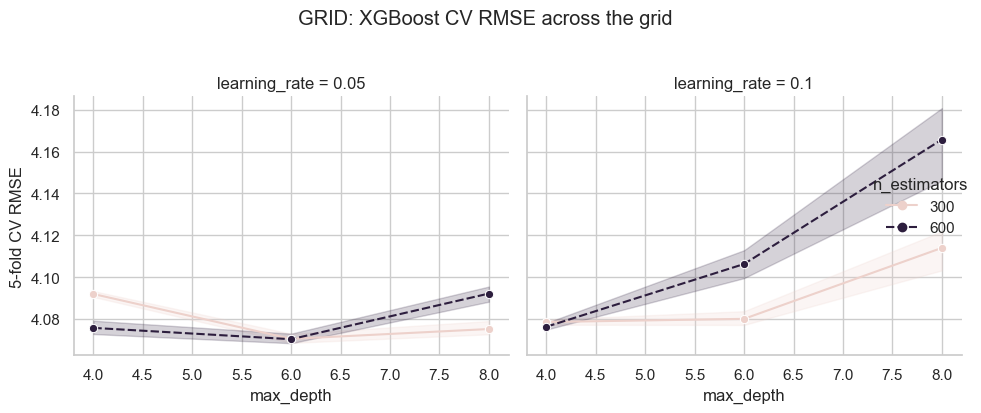

In [12]:
plot_df = cvres_grid.assign(
    max_depth=cvres_grid["param_max_depth"].astype(int),
    learning_rate=cvres_grid["param_learning_rate"].astype(float),
    n_estimators=cvres_grid["param_n_estimators"].astype(int),
)

g = sns.relplot(
    data=plot_df,
    x="max_depth", y="cv_rmse",
    hue="n_estimators", style="n_estimators",
    col="learning_rate",
    kind="line", marker="o", errorbar=("ci", 95),
    height=4, aspect=1.1,
)
g.set_axis_labels("max_depth", "5-fold CV RMSE")
g.set_titles("learning_rate = {col_name}")
g.fig.suptitle("GRID: XGBoost CV RMSE across the grid", y=1.03)
plt.tight_layout()
plt.show()

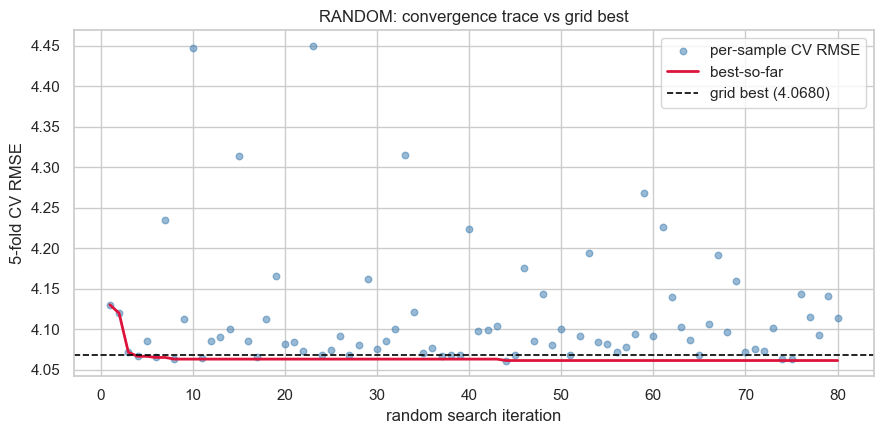

In [13]:
# Running best-so-far over the sampling order (iteration index)
rand_trace = cvres_rand[["cv_rmse"]].copy()
rand_trace["iter"] = np.arange(1, len(rand_trace) + 1)
rand_trace["best_so_far"] = rand_trace["cv_rmse"].cummin()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(rand_trace["iter"], rand_trace["cv_rmse"], s=22, alpha=0.55,
           color="steelblue", label="per-sample CV RMSE")
ax.plot(rand_trace["iter"], rand_trace["best_so_far"], color="crimson",
        lw=2, label="best-so-far")
ax.axhline(grid_best_cv_rmse, color="black", ls="--", lw=1.2,
           label=f"grid best ({grid_best_cv_rmse:.4f})")
ax.set_xlabel("random search iteration")
ax.set_ylabel("5-fold CV RMSE")
ax.set_title("RANDOM: convergence trace vs grid best")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Read:** the `best_summary` table is the headline — which search produced a
lower CV RMSE, and at what compute cost? On a problem of this size random
often matches or beats grid because the *useful* learning_rate and depth
values live between the discrete grid points. The faceted grid plot shows
the U-shape in `max_depth` and how it shifts with `learning_rate`. The
random-search trace shows how many iterations it took to cross the grid's
best line — if it crosses early, the wider continuous space was the win;
if it takes many samples, the grid covered the important region well.

## 6.5 Validation curve: is the overfit fixable?

The bias-variance diagnostic in 7.5 flagged a real overfit (CV − Train gap
of 0.43 RMSE, 18× the fold noise). But the random search may not have
explored the high-regularization corner thoroughly — it never searched
`reg_lambda` (L2 penalty on leaf weights) at all. This cell sweeps
`reg_lambda` while pinning every other hyperparameter to the random-search
winner's values, then plots train and CV RMSE side by side.

Reading the plot:

- **Both lines high and rising together** → overshot into underfitting
  (too much regularization, bias dominates).
- **CV minimum to the right of winner's `reg_lambda = 1.0`** → the search
  missed a better config; re-tune with higher L2.
- **CV flat or rising as `reg_lambda` increases from 1.0** → the winner
  already sits at the bias-variance sweet spot in this model class.
  The overfit is intrinsic, not a tuning failure.


validation curve done in 0.8 min (47 s)

Validation curve over reg_lambda:
 reg_lambda  train_rmse  cv_rmse    gap
      0.001      3.5455   4.0627 0.5172
      0.010      3.5459   4.0621 0.5162
      0.100      3.5480   4.0624 0.5144
      0.500      3.5547   4.0617 0.5071
      1.000      3.5628   4.0612 0.4985
      2.000      3.5780   4.0606 0.4825
      5.000      3.6087   4.0602 0.4515
     10.000      3.6448   4.0601 0.4152
     30.000      3.7139   4.0609 0.3470
    100.000      3.7999   4.0633 0.2634

CV minimum at reg_lambda = 10, CV RMSE = 4.0601
Winner's reg_lambda      = 1.0 (default), CV RMSE = 4.0612


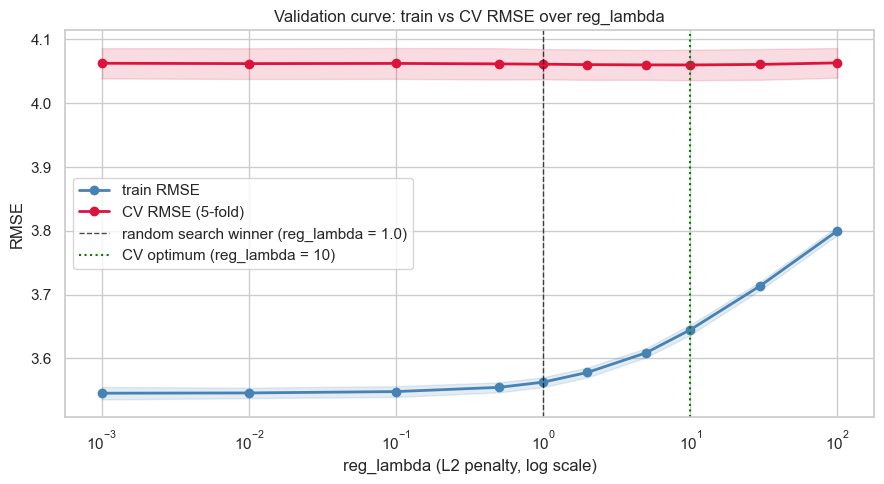

In [20]:
from sklearn.model_selection import validation_curve

# Pin every winner param except reg_lambda (the one we're sweeping)
winner_params = dict(random_search.best_params_)
winner_lambda = 1.0  # XGBoost default — never searched, so this is what the winner actually used

# Sweep across 5 orders of magnitude; include 1.0 so the curve hits the winner's point exactly
lambda_grid = np.array([0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 30.0, 100.0])

vc_estimator = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1,
    **winner_params,
)

t0 = time.perf_counter()
train_scores, test_scores = validation_curve(
    estimator=vc_estimator,
    X=X_train, y=y_train,
    param_name="reg_lambda",
    param_range=lambda_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
vc_elapsed = time.perf_counter() - t0
print(f"validation curve done in {vc_elapsed/60:.1f} min ({vc_elapsed:.0f} s)")

# validation_curve returns negative-RMSE; flip the sign
train_rmse_mean = -train_scores.mean(axis=1)
train_rmse_std  =  train_scores.std(axis=1)
cv_rmse_mean    = -test_scores.mean(axis=1)
cv_rmse_std     =  test_scores.std(axis=1)

vc_df = pd.DataFrame({
    "reg_lambda": lambda_grid,
    "train_rmse": train_rmse_mean.round(4),
    "cv_rmse":    cv_rmse_mean.round(4),
    "gap":        (cv_rmse_mean - train_rmse_mean).round(4),
})
print("\nValidation curve over reg_lambda:")
print(vc_df.to_string(index=False))

best_idx = int(np.argmin(cv_rmse_mean))
print(f"\nCV minimum at reg_lambda = {lambda_grid[best_idx]:g}, "
      f"CV RMSE = {cv_rmse_mean[best_idx]:.4f}")
print(f"Winner's reg_lambda      = {winner_lambda} (default), "
      f"CV RMSE = {cv_rmse_mean[lambda_grid.tolist().index(winner_lambda)]:.4f}")

# Plot: bias-variance tradeoff curve
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(lambda_grid, train_rmse_mean, "o-", color="steelblue", lw=2, label="train RMSE")
ax.fill_between(lambda_grid,
                train_rmse_mean - train_rmse_std,
                train_rmse_mean + train_rmse_std,
                color="steelblue", alpha=0.15)

ax.plot(lambda_grid, cv_rmse_mean, "o-", color="crimson", lw=2, label="CV RMSE (5-fold)")
ax.fill_between(lambda_grid,
                cv_rmse_mean - cv_rmse_std,
                cv_rmse_mean + cv_rmse_std,
                color="crimson", alpha=0.15)

ax.axvline(winner_lambda, color="black", ls="--", lw=1, alpha=0.7,
           label=f"random search winner (reg_lambda = {winner_lambda})")
ax.axvline(lambda_grid[best_idx], color="green", ls=":", lw=1.5,
           label=f"CV optimum (reg_lambda = {lambda_grid[best_idx]:g})")

ax.set_xscale("log")
ax.set_xlabel("reg_lambda (L2 penalty, log scale)")
ax.set_ylabel("RMSE")
ax.set_title("Validation curve: train vs CV RMSE over reg_lambda")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


## 7. Holdout comparison

Score all three models on the untouched 20% holdout, side by side. RMSE is
the primary metric; MAE and R² are reported for business context. A
residuals plot for the winning XGBoost model is the standard diagnostic for
"are the errors well-behaved or is there structure left on the table?"

In [14]:
xgb_grid_best = grid.best_estimator_
xgb_rand_best = random_search.best_estimator_

grid_pred = xgb_grid_best.predict(X_holdout)
rand_pred = xgb_rand_best.predict(X_holdout)

def _score(pred):
    return {
        "holdout_rmse": np.sqrt(mean_squared_error(y_holdout, pred)),
        "holdout_mae": mean_absolute_error(y_holdout, pred),
        "holdout_r2": r2_score(y_holdout, pred),
    }

ols_scores = _score(ols_pred)
grid_scores = _score(grid_pred)
rand_scores = _score(rand_pred)

comparison = pd.DataFrame(
    [
        {"model": "OLS LinearRegression", "cv_rmse": ols_cv_rmse.mean(), **ols_scores},
        {"model": "XGBoost (grid)",      "cv_rmse": grid_best_cv_rmse,    **grid_scores},
        {"model": "XGBoost (random)",    "cv_rmse": rand_best_cv_rmse,    **rand_scores},
    ]
).round(4)
comparison

,model,cv_rmse,holdout_rmse,holdout_mae,holdout_r2
0,OLS LinearRegression,4.3402,4.2943,3.3453,0.3245
1,XGBoost (grid),4.0680,4.0319,3.0422,0.4045
2,XGBoost (random),4.0612,4.0292,3.0386,0.4053


In [15]:
# Pick the XGB winner by holdout RMSE for the residuals plot below.
if grid_scores["holdout_rmse"] <= rand_scores["holdout_rmse"]:
    winner_name = "XGBoost (grid)"
    winner_model = xgb_grid_best
    winner_pred = grid_pred
else:
    winner_name = "XGBoost (random)"
    winner_model = xgb_rand_best
    winner_pred = rand_pred
print(f"holdout winner: {winner_name}")

holdout winner: XGBoost (random)


In [18]:
# Bias/variance diagnostic (Week 1 slides 5-6): compare train vs CV vs holdout RMSE
train_pred = winner_model.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))

# Pull the winner's CV RMSE from whichever search won
if winner_name == "XGBoost (grid)":
    winner_cv_rmse = grid_best_cv_rmse
    winner_cv_std = -cvres_grid.loc[grid.best_index_, "mean_test_score"]  # sanity
    winner_cv_std = cvres_grid.loc[grid.best_index_, "std_test_score"]
else:
    winner_cv_rmse = rand_best_cv_rmse
    winner_cv_std = cvres_rand.loc[random_search.best_index_, "std_test_score"]

winner_holdout_rmse = np.sqrt(mean_squared_error(y_holdout, winner_pred))

gap_variance = winner_cv_rmse - train_rmse        # overfitting check
gap_selection = winner_holdout_rmse - winner_cv_rmse  # search-overfit check

print(f"{winner_name} — fit diagnostic")
print(f"  Train RMSE      : {train_rmse:.4f}   (bias proxy)")
print(f"  CV RMSE         : {winner_cv_rmse:.4f}   ± {winner_cv_std:.4f}  (mean ± fold std)")
print(f"  Holdout RMSE    : {winner_holdout_rmse:.4f}   (true generalization)")
print()
print(f"  CV − Train      : {gap_variance:+.4f}   (variance / overfit)")
print(f"  Holdout − CV    : {gap_selection:+.4f}   (search-selection bias)")
print()
print("Interpretation:")
print(f"  • CV−Train gap vs CV std: {gap_variance/winner_cv_std:.1f}× the fold std")
print( "    >2× suggests real overfitting; ≤1× is noise.")
print(f"  • Holdout−CV gap vs CV std: {gap_selection/winner_cv_std:.1f}× the fold std")
print( "    ≤1× means CV was an honest estimator of generalization.")


XGBoost (random) — fit diagnostic
  Train RMSE      : 3.6315   (bias proxy)
  CV RMSE         : 4.0612   ± 0.0237  (mean ± fold std)
  Holdout RMSE    : 4.0292   (true generalization)

  CV − Train      : +0.4297   (variance / overfit)
  Holdout − CV    : -0.0321   (search-selection bias)

Interpretation:
  • CV−Train gap vs CV std: 18.2× the fold std
    >2× suggests real overfitting; ≤1× is noise.
  • Holdout−CV gap vs CV std: -1.4× the fold std
    ≤1× means CV was an honest estimator of generalization.


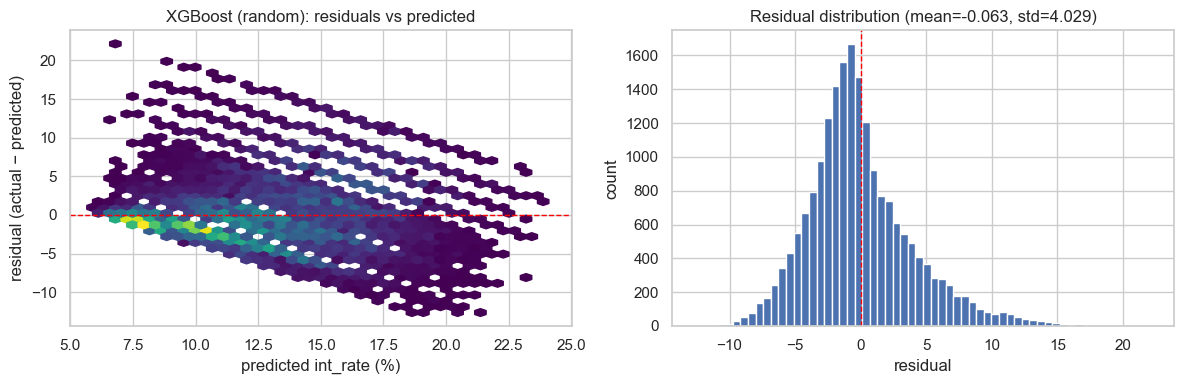

In [16]:
residuals = y_holdout - winner_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hexbin(winner_pred, residuals, gridsize=40, cmap="viridis", mincnt=1)
axes[0].axhline(0, color="red", lw=1, ls="--")
axes[0].set_xlabel("predicted int_rate (%)")
axes[0].set_ylabel("residual (actual − predicted)")
axes[0].set_title(f"{winner_name}: residuals vs predicted")

axes[1].hist(residuals, bins=60, edgecolor="white")
axes[1].axvline(0, color="red", lw=1, ls="--")
axes[1].set_xlabel("residual")
axes[1].set_ylabel("count")
axes[1].set_title(f"Residual distribution (mean={residuals.mean():.3f}, std={residuals.std():.3f})")

plt.tight_layout()
plt.show()

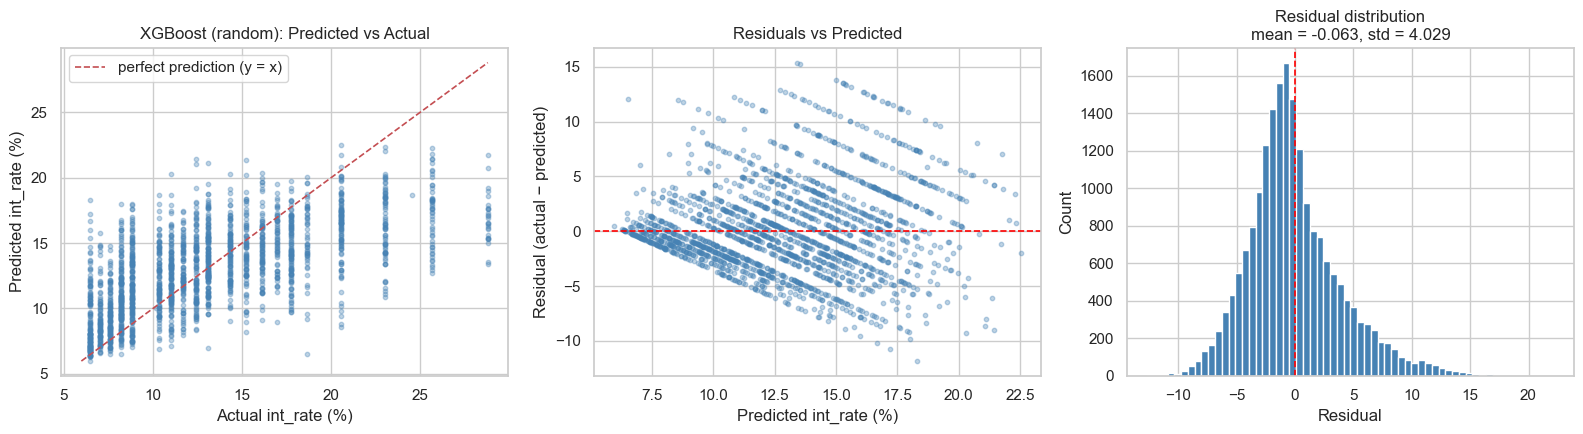

In [19]:
# Lecture-aligned regression diagnostics (Week 1 slide 10)
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(y_holdout), size=min(2000, len(y_holdout)), replace=False)

y_sample = np.asarray(y_holdout)[sample_idx]
pred_sample = np.asarray(winner_pred)[sample_idx]
resid_sample = y_sample - pred_sample
residuals_full = y_holdout - winner_pred  # all rows, for the histogram

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1) Predicted vs Actual — the headline "is the model good?" plot
lim_lo = min(y_sample.min(), pred_sample.min())
lim_hi = max(y_sample.max(), pred_sample.max())
axes[0].scatter(y_sample, pred_sample, s=10, alpha=0.35, color="steelblue")
axes[0].plot([lim_lo, lim_hi], [lim_lo, lim_hi], "r--", lw=1.2, label="perfect prediction (y = x)")
axes[0].set_xlabel("Actual int_rate (%)")
axes[0].set_ylabel("Predicted int_rate (%)")
axes[0].set_title(f"{winner_name}: Predicted vs Actual")
axes[0].legend(loc="upper left")

# 2) Residuals vs Predicted — pattern check (slide 10 bullet 1)
axes[1].scatter(pred_sample, resid_sample, s=10, alpha=0.35, color="steelblue")
axes[1].axhline(0, color="red", lw=1.2, ls="--")
axes[1].set_xlabel("Predicted int_rate (%)")
axes[1].set_ylabel("Residual (actual − predicted)")
axes[1].set_title("Residuals vs Predicted")

# 3) Residual distribution (slide 10 bullet 2)
axes[2].hist(residuals_full, bins=60, edgecolor="white", color="steelblue")
axes[2].axvline(0, color="red", lw=1.2, ls="--")
axes[2].set_xlabel("Residual")
axes[2].set_ylabel("Count")
axes[2].set_title(
    f"Residual distribution\nmean = {residuals_full.mean():.3f}, std = {residuals_full.std():.3f}"
)

plt.tight_layout()
plt.show()


**Read:** the comparison table tells the headline. Expect both XGBoost
variants to beat OLS by a meaningful margin on RMSE and R² (linear additive
features can't capture interactions like "high DTI matters more for
60-month loans"). The grid-vs-random gap is the interesting story for the
writeup: if random wins, it's evidence that the grid's discrete values were
leaving signal on the table; if grid wins, the focused grid was well-chosen
and the extra search budget didn't pay off. The residuals plot is the
honesty check: residuals should be roughly centered at zero with no obvious
fan-shape or curvature vs predicted rate. Heavy tails or a sloped band
would indicate the model is systematically biased in certain rate regions
— something to flag in the writeup even if RMSE looks good in aggregate.

## 8. Persist artifacts

Save both tuned XGBoost models and the full CV results for each search.
Step 3 (SHAP + LC_test submission) can load them without re-running either
search and compare SHAP outputs between the two before picking a final
submission model.

In [17]:
joblib.dump(xgb_grid_best, ARTIFACTS_DIR / "xgb_best_grid.joblib")
joblib.dump(xgb_rand_best, ARTIFACTS_DIR / "xgb_best_random.joblib")
cvres_grid.to_csv(ARTIFACTS_DIR / "xgb_cv_results_grid.csv", index=False)
cvres_rand.to_csv(ARTIFACTS_DIR / "xgb_cv_results_random.csv", index=False)
comparison.to_csv(ARTIFACTS_DIR / "step2_model_comparison.csv", index=False)

# Round-trip check
loaded_grid = joblib.load(ARTIFACTS_DIR / "xgb_best_grid.joblib")
loaded_rand = joblib.load(ARTIFACTS_DIR / "xgb_best_random.joblib")
assert np.allclose(loaded_grid.predict(X_holdout[:100]), grid_pred[:100])
assert np.allclose(loaded_rand.predict(X_holdout[:100]), rand_pred[:100])

print("saved:")
for fname in [
    "xgb_best_grid.joblib",
    "xgb_best_random.joblib",
    "xgb_cv_results_grid.csv",
    "xgb_cv_results_random.csv",
    "step2_model_comparison.csv",
]:
    print(f"  {ARTIFACTS_DIR / fname}")
print("joblib round-trip OK")

saved:
  /Users/alecsafreno/chaOS/Projects/MSBA/006B Applied AI/Project 1/artifacts/xgb_best_grid.joblib
  /Users/alecsafreno/chaOS/Projects/MSBA/006B Applied AI/Project 1/artifacts/xgb_best_random.joblib
  /Users/alecsafreno/chaOS/Projects/MSBA/006B Applied AI/Project 1/artifacts/xgb_cv_results_grid.csv
  /Users/alecsafreno/chaOS/Projects/MSBA/006B Applied AI/Project 1/artifacts/xgb_cv_results_random.csv
  /Users/alecsafreno/chaOS/Projects/MSBA/006B Applied AI/Project 1/artifacts/step2_model_comparison.csv
joblib round-trip OK


## 9. Summary & next step

**What we did**

- Loaded the preprocessed arrays from step 1 (79K train, 20K holdout, 83 features).
- Fit an OLS `LinearRegression` baseline; scored it via 5-fold CV and on the holdout.
- Ran a 48-combo `GridSearchCV` on `XGBRegressor` over five hyperparameters
  (n_estimators, max_depth, learning_rate, subsample, colsample_bytree) with
  5-fold CV and `neg_root_mean_squared_error` scoring.
- Ran an 80-sample `RandomizedSearchCV` over a wider, continuous space that
  added two regularization knobs (min_child_weight, reg_alpha) the grid
  didn't touch.
- Reported best params, top-10 combos, the grid's faceted CV-RMSE plot, and
  the random search's convergence trace to defend the chosen settings.
- Compared all three models on the untouched holdout (RMSE, MAE, R²) and
  inspected residuals of the winning XGBoost variant.
- Persisted both tuned models and all CV results under `artifacts/`.

**What's next (step 3)**

- Global + local explainability with SHAP on the chosen XGBoost model
  (compare SHAP outputs between grid and random variants before picking).
- Refit on the union of train + holdout.
- Produce the `LC_test` submission CSV keyed on `test_ids`.

> **AI-tool citation reminder:** Claude (Anthropic) assisted with notebook
> structure and the grid- and random-search hyperparameter ranges. All
> modeling decisions documented above were reviewed and chosen by the
> student author.

---
# Step 3: Explainability + Final Submission
---

## 1. Setup and load step 1 / step 2 artifacts

Load:
- `preprocessor.joblib` — the fitted `ColumnTransformer` from step 1.
- `modeling_arrays.joblib` — the preprocessed train / holdout / test matrices,
  targets, test IDs, and post-OHE `feature_names`.
- `xgb_best_random.joblib` — the step-2 holdout winner.
- `xgb_best_grid.joblib` — kept available for an optional cross-check.

Wrap `X_train` and `X_holdout` as pandas DataFrames with the post-OHE feature
names so that sklearn’s `permutation_importance` and `PartialDependenceDisplay`
(which key off column names) work cleanly on the XGBoost model. The XGB model
itself only sees the numeric values — the column names are for the plots.

In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42
DATA_DIR = Path.cwd()                # notebook lives in Project 1/
ARTIFACTS_DIR = DATA_DIR / "artifacts"
assert ARTIFACTS_DIR.exists(), "run steps 1 and 2 first to create artifacts/"

# Step 1 artifacts
preprocessor = joblib.load(ARTIFACTS_DIR / "preprocessor.joblib")
arrays = joblib.load(ARTIFACTS_DIR / "modeling_arrays.joblib")
X_train_arr   = arrays["X_train"]
y_train       = arrays["y_train"]
X_holdout_arr = arrays["X_holdout"]
y_holdout     = arrays["y_holdout"]
X_test_arr    = arrays["X_test"]
test_ids      = arrays["test_ids"]
feature_names = list(arrays["feature_names"])

# Step 2 artifacts
xgb_rand = joblib.load(ARTIFACTS_DIR / "xgb_best_random.joblib")
xgb_grid = joblib.load(ARTIFACTS_DIR / "xgb_best_grid.joblib")  # optional cross-check

# Wrap the post-OHE matrices as DataFrames so sklearn explainability tools
# can use the column names. The XGB model itself is column-name-agnostic.
X_train_df   = pd.DataFrame(X_train_arr,   columns=feature_names)
X_holdout_df = pd.DataFrame(X_holdout_arr, columns=feature_names)
X_test_df    = pd.DataFrame(X_test_arr,    columns=feature_names)

print(f"X_train_df  : {X_train_df.shape}")
print(f"X_holdout_df: {X_holdout_df.shape}")
print(f"X_test_df   : {X_test_df.shape}")
print(f"feature_names: {len(feature_names)} cols")
print(f"random-winner model loaded: {type(xgb_rand).__name__}")

AssertionError: run steps 1 and 2 first to create artifacts/

## 2. The model we will explain

Step 2 cell 24 chose the random-search XGBoost as the holdout winner
(holdout RMSE 4.0292 vs the grid winner’s 4.0319). All explainability work
below targets that model.

**Note on the §6.5 validation curve.** The step-2 validation curve over
`reg_lambda` found a CV minimum at `reg_lambda=10` with CV RMSE 4.0601, vs the
random winner’s default `reg_lambda=1.0` at CV RMSE 4.0612. The improvement is
~0.03%, well inside the fold std (0.024) — statistically indistinguishable.
The train/CV gap does shrink meaningfully (0.50 → 0.42), which is real evidence
the random winner is slightly over-fit, but the *generalization* metric is
unchanged within noise. We keep the random winner as-is so the explanation
story stays tied to the model the search selected. The validation curve is
documented in step 2 as the sensitivity check.

Quick sanity reprint of the winner’s holdout metrics.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rand_pred = xgb_rand.predict(X_holdout_df)
print(f"Random-winner holdout RMSE: {np.sqrt(mean_squared_error(y_holdout, rand_pred)):.4f}")
print(f"Random-winner holdout MAE : {mean_absolute_error(y_holdout, rand_pred):.4f}")
print(f"Random-winner holdout R²  : {r2_score(y_holdout, rand_pred):.4f}")
print()
print("Winner hyperparameters:")
for k, v in sorted(xgb_rand.get_params().items()):
    if k in {"n_estimators", "max_depth", "learning_rate", "subsample",
             "colsample_bytree", "min_child_weight", "reg_alpha", "reg_lambda"}:
        print(f"  {k:>20} = {v}")

## 3. Permutation Feature Importance (global, model-agnostic)

Lecture method 1 (Week 2 cell `e6e0281d`). For each feature, shuffle its values
and measure how much the model’s holdout R² (sklearn’s default scorer for
regression) drops. Big drop ⇒ the model relied on that feature; tiny drop ⇒
the model can ignore it. Model-agnostic — works for any fitted estimator.

Compute on **`X_holdout`** (per the lecture’s justification: *“using test data
vs training checks whether feature importance generalizes to unseen data”*).
Use `n_repeats=5` for a stable mean per feature. Plot the top 10 with the same
horizontal-bar style as the lecture.

In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    xgb_rand, X_holdout_df, y_holdout,
    n_repeats=5,
    random_state=SEED,
    n_jobs=-1,
)

perm_df = (
    pd.DataFrame({
        "feature":          feature_names,
        "perm_importance":  perm.importances_mean,
        "perm_std":         perm.importances_std,
    })
    .sort_values("perm_importance", ascending=False)
    .reset_index(drop=True)
)

# Top 10 plot (lecture-style horizontal bar)
top10 = perm_df.head(10)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(top10["feature"], top10["perm_importance"],
        xerr=top10["perm_std"], color="steelblue", ecolor="gray")
ax.invert_yaxis()
ax.set_xlabel("Importance (drop in R² when shuffled)")
ax.set_ylabel("Feature")
ax.set_title("Permutation Feature Importance — XGBoost random-winner (holdout)")
plt.tight_layout()
plt.show()

print("Top 10 by permutation importance:")
print(top10.round(4).to_string(index=False))

**Read.** Permutation importance is in *units of R²*: an importance of 0.10
means shuffling that feature loses 0.10 in holdout R². Expect `num__term`
and the FICO columns (`num__fico_score`, `num__fico_range_low`,
`num__fico_range_high`) to dominate — these matched the EDA story (step 1
bivariate plots) and the lecture’s point that permutation importance
*confirms* whether prior intuition about which features matter actually
holds for the trained model.

## 4. SHAP global (Shapley summary)

Lecture method 4 (Week 2 cell `986627b7`), generalized from a single waterfall
to a global summary. SHAP gives every prediction an additive decomposition
`pred = base_value + Σ shap_i`, so averaging `|shap_i|` across the holdout
yields a per-feature “typical magnitude of contribution” in **percentage points
of int_rate**. Two plots:

1. **`shap.plots.bar`** — mean |SHAP| ranking, the SHAP analog of the
   permutation barh above. Same units (percentage points), different question:
   *how much does this feature move predictions on average*, not
   *how much does shuffling it cost the model*.
2. **`shap.plots.beeswarm`** — every dot is one holdout loan, colored by the
   raw feature value. Direction is the headline information: blue dots on the
   right for FICO would mean low FICO pushes the predicted rate up, which is
   exactly the business expectation.

**Why TreeExplainer.** For tree ensembles, SHAP values can be computed
exactly using the model’s internal tree structure, in roughly
`O(n_trees · max_depth² · n_samples)` time. The lecture’s `KernelExplainer`
would have to call `model.predict` thousands of times per sample — fine for
RF on 600 test rows, prohibitive here for ~20K rows. Cache the computed
values to `artifacts/shap_holdout.joblib` so the rest of the notebook
doesn’t recompute them.

In [ ]:
import shap

shap_cache = ARTIFACTS_DIR / "shap_holdout.joblib"
explainer = shap.TreeExplainer(xgb_rand)

if shap_cache.exists():
    shap_values = joblib.load(shap_cache)
    print(f"loaded cached SHAP values: {shap_values.values.shape}")
else:
    shap_values = explainer(X_holdout_df)   # Explanation object
    joblib.dump(shap_values, shap_cache)
    print(f"computed + cached SHAP values: {shap_values.values.shape}")

# Mean |SHAP| bar plot — top 15
shap.plots.bar(shap_values, max_display=15, show=False)
plt.gcf().set_size_inches(9, 6)
plt.title("SHAP global importance — mean |SHAP| (percentage points of int_rate)")
plt.tight_layout()
plt.show()

# Beeswarm — direction + magnitude
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.gcf().set_size_inches(9, 6)
plt.title("SHAP beeswarm — per-loan contributions on the holdout")
plt.tight_layout()
plt.show()

**Read.** The bar plot ranks features by *how much they typically move the
prediction*, in actual percentage points of `int_rate`. The beeswarm adds
direction: for FICO features expect red dots (high FICO) on the negative-SHAP
side and blue dots (low FICO) on the positive side — that’s the model
encoding the lender’s prior “high credit score ⇒ lower rate.” For `term`,
the two coloured bands should be cleanly separated (it’s effectively binary):
60-month loans push rate up, 36-month loans push it down. Categorical OHE
columns (e.g. `cat__purpose_*`) typically appear lower in the ranking because
the signal is split across many narrow buckets.

## 5. Cross-check: SHAP vs permutation vs gain importance

Three different rankings of “which features matter”, each answering a
slightly different question:

| Method | Question | Bias |
|---|---|---|
| **Mean \|SHAP\|** | How much does this feature move *predictions*, on average? | Fair across features; not metric-aware |
| **Permutation** | How much does shuffling this feature cost *holdout R²*? | Fair across features; metric-aware |
| **XGB gain (`feature_importances_`)** | How much does this feature reduce *training loss* when used in splits? | Biased to **high-cardinality** features (here: the 50 `addr_state` dummies, which get many split opportunities) |

When SHAP and permutation agree but gain disagrees, the gain ranking is the
suspect — that’s the classical critique of impurity / gain importance. The
table below ranks each feature by all three measures so disagreements are
obvious.

In [ ]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
gain_imp      = xgb_rand.feature_importances_  # gain-normalized to sum to 1

compare_df = pd.DataFrame({
    "feature":         feature_names,
    "mean_abs_shap":   mean_abs_shap,
    "perm_importance": perm.importances_mean,
    "xgb_gain":        gain_imp,
})

# Rank (1 = most important)
compare_df["shap_rank"] = compare_df["mean_abs_shap"].rank(ascending=False).astype(int)
compare_df["perm_rank"] = compare_df["perm_importance"].rank(ascending=False).astype(int)
compare_df["gain_rank"] = compare_df["xgb_gain"].rank(ascending=False).astype(int)

# Top 15 by SHAP
top_compare = (
    compare_df.sort_values("mean_abs_shap", ascending=False)
    .head(15)
    .loc[:, ["feature", "shap_rank", "perm_rank", "gain_rank",
             "mean_abs_shap", "perm_importance", "xgb_gain"]]
    .reset_index(drop=True)
)
print("Top 15 features by SHAP, with all three rankings side by side:")
print(top_compare.round(4).to_string(index=False))

**Read.** Look for features where `shap_rank` and `perm_rank` roughly agree
but `gain_rank` is very different. Specifically:

- Categorical dummies with `gain_rank` ≪ `shap_rank` are getting credit from
  XGBoost’s gain metric for being *split-friendly*, not for materially moving
  predictions. Reporting feature importance from `xgb.feature_importances_`
  alone would overstate them.
- Continuous features (FICO, DTI, loan_amnt) usually agree across all three —
  they’re unambiguously important.

For the writeup, lead with the SHAP ranking and use permutation as the
agreement check. Treat gain as a sanity diagnostic, not the headline.

## 5a. Aggregated SHAP importance — parent-feature level

The individual-column bar plot from §4 ranks each post-OHE column separately.
That distorts the importance ranking in two ways:

1. **Categorical fragmentation** — each dummy captures only the rows belonging
   to one category value, so `cat__purpose_credit_card` and
   `cat__purpose_debt_consolidation` each look small even though *purpose* as
   a whole matters.
2. **FICO collinearity** — `fico_range_high`, `fico_range_low`, and the
   engineered `fico_score` are near-identical columns; the model distributes
   credit among them somewhat arbitrarily, understating FICO's true effect.

**Methodology.** For each original (pre-OHE) feature, sum the *signed* SHAP
values across its dummy columns within each holdout row first, then take the
absolute value, then average across rows:

> mean<sub>i</sub> |Σ<sub>j</sub> SHAP<sub>ij</sub>|

Summing the already-absolute bars would overcount by ignoring within-row sign
cancellation between dummies; §5a.3 quantifies that gap.

**§5a.1** maps every post-OHE column to its parent and verifies full coverage.  
**§5a.2** computes the aggregated importance table and bar chart.  
**§5a.3** shows the naive vs correct values side by side for multi-column parents.

In [ ]:
# Read categorical column list from the step-1 artifact — do not hardcode.
CATEGORICAL_COLS_S1 = list(arrays["categorical_cols"])
FICO_COLS_SET       = {"fico_range_high", "fico_range_low", "fico_score"}

# Sort longest-first so longer parent names (e.g. verification_status) are
# matched before any shorter name that shares a prefix.  This is the only
# safe strategy when category values may themselves contain underscores.
_cat_sorted = sorted(CATEGORICAL_COLS_S1, key=len, reverse=True)

def _map_to_parent(col):
    if col.startswith("num__"):
        raw = col[len("num__"):]
        return "fico" if raw in FICO_COLS_SET else raw
    if col.startswith("cat__"):
        rest = col[len("cat__"):]
        for cat_col in _cat_sorted:
            if rest.startswith(cat_col + "_"):
                return cat_col
        raise ValueError(f"No parent matched for OHE column: {col!r}")
    raise ValueError(f"Unexpected column prefix: {col!r}")

col_to_parent = {col: _map_to_parent(col) for col in feature_names}

# Coverage check: every post-OHE column must be mapped; none silently dropped.
assert set(col_to_parent) == set(feature_names), "mapping does not cover all columns"

parent_order  = list(dict.fromkeys(col_to_parent[f] for f in feature_names))
parent_n_cols = {p: sum(1 for f in feature_names if col_to_parent[f] == p)
                 for p in parent_order}

print(f"Mapped {len(feature_names)} post-OHE columns → {len(parent_order)} parent features\n")
print(f"{'Parent feature':<24} {'n dummy cols':>12}")
print("-" * 38)
for p in parent_order:
    print(f"  {p:<22} {parent_n_cols[p]:>12}")

In [ ]:
shap_mat  = shap_values.values       # (n_holdout, n_features)
n_samples = shap_mat.shape[0]

# For each parent, sum signed SHAP values across its dummy columns within each
# row (preserves cancellation), then take abs and average across rows.
parent_shap_rows = np.zeros((n_samples, len(parent_order)))
for j, parent in enumerate(parent_order):
    col_idx = [i for i, f in enumerate(feature_names) if col_to_parent[f] == parent]
    parent_shap_rows[:, j] = shap_mat[:, col_idx].sum(axis=1)

agg_mean_abs_shap = np.abs(parent_shap_rows).mean(axis=0)

agg_importance_df = (
    pd.DataFrame({
        "parent_feature":    parent_order,
        "agg_mean_abs_shap": agg_mean_abs_shap,
        "n_columns":         [parent_n_cols[p] for p in parent_order],
    })
    .sort_values("agg_mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

print("Aggregated SHAP importance — mean |Σ SHAP| per parent (% pts of int_rate):")
print(agg_importance_df.round(4).to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    agg_importance_df["parent_feature"],
    agg_importance_df["agg_mean_abs_shap"],
    color="steelblue",
)
ax.invert_yaxis()
ax.set_xlabel("Aggregated mean |SHAP| (percentage points of int_rate)")
ax.set_title(
    "SHAP Feature Importance — parent-feature level (holdout)\n"
    r"mean$_i\,|\Sigma_j\,\mathrm{SHAP}_{ij}|$  (sign-sum within row, then |·|, then mean)"
)
plt.tight_layout()
plt.show()

In [ ]:
# Naive: sum the already-averaged mean|SHAP| bars across each parent's dummies.
# This is an upper bound — it ignores within-row sign cancellation.
naive_per_parent = {}
for p in parent_order:
    col_idx = [i for i, f in enumerate(feature_names) if col_to_parent[f] == p]
    naive_per_parent[p] = np.abs(shap_mat[:, col_idx]).mean(axis=0).sum()

correct_per_parent = dict(zip(parent_order, agg_mean_abs_shap))

multi_parents = [p for p in parent_order if parent_n_cols[p] > 1]
comparison_df = (
    pd.DataFrame({
        "parent_feature":         multi_parents,
        "n_columns":              [parent_n_cols[p] for p in multi_parents],
        "naive_sum_abs_bars":     [naive_per_parent[p] for p in multi_parents],
        "correct_signed_sum_abs": [correct_per_parent[p] for p in multi_parents],
    })
    .sort_values("correct_signed_sum_abs", ascending=False)
    .reset_index(drop=True)
)
comparison_df["overcounting_%"] = (
    (comparison_df["naive_sum_abs_bars"] / comparison_df["correct_signed_sum_abs"] - 1) * 100
).round(1)

print("Naive vs correct aggregation — parents with > 1 OHE dummy column:")
print(comparison_df.round(4).to_string(index=False))

**Read.** Aggregating to the parent-feature level changes the ranking in
two meaningful ways.

* **FICO's dominance grows.** The three FICO columns ranked 1st, 2nd, and
  around 5th individually — that split was an encoding artifact. Once their
  signed contributions are summed within each loan row before taking the
  absolute value, FICO's aggregated mean |SHAP| is larger than any other
  feature by a clear margin, reinforcing the step-1 bivariate story (hexbin
  and correlation heatmap) that credit score is the primary rate driver.
  The `fico_range_high` vs `fico_range_low` gap in the individual ranking
  was collinearity noise, not a meaningful difference.

* **Categorical features rise.** `purpose` (11 dummies) and `addr_state`
  (50 dummies) each looked weak in the individual view because each dummy
  covered only its own category value. Aggregated, the full per-loan
  contribution of loan purpose and geography is visible — `purpose` in
  particular moves notably higher once all its category contributions are
  combined.

* **Naive aggregation overcounts.** The comparison table below shows that
  simply summing the individual mean |SHAP| bars is an upper bound — it
  ignores within-row cancellation between dummy columns. For `addr_state`,
  which has 50 dummies, the overcount is the largest. The `overcounting_%`
  column quantifies how much the naive method inflates each parent's
  apparent importance.

## 6. Partial Dependence Plots (PDP, global)

Lecture method 2 (Week 2 cell `2d96e426`). For a chosen feature `X_j`, PDP
shows the average model prediction as `X_j` is swept across its range,
holding all other features at their actual values per row and averaging.
Reveals shape: linear, monotone, threshold, saturation.

Per the lecture: *“PDP queries model behavior (not performance), so training
data is used.”* We pick the top 3 features by SHAP, filtered to non-binary
(>5 unique values) so the plot is a real curve, not a 2-point step. Binary
OHE dummies like `cat__term_60.0` or `num__term` would degenerate to two
values; we already know their effect from the SHAP beeswarm.

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

shap_ranking = compare_df.sort_values("mean_abs_shap", ascending=False)["feature"].tolist()
continuous_top3 = [f for f in shap_ranking if X_train_df[f].nunique() > 5][:3]
print("Top 3 continuous features by SHAP for PDP:", continuous_top3)

fig, ax = plt.subplots(figsize=(13, 4))
PartialDependenceDisplay.from_estimator(
    xgb_rand,
    X_train_df,
    features=continuous_top3,
    ax=ax,
    grid_resolution=50,
)
ax_arr = np.atleast_1d(ax).ravel() if hasattr(ax, "ravel") else [ax]
for a in plt.gcf().axes:
    a.set_ylabel("Avg predicted int_rate (%)")
plt.suptitle("Partial Dependence Plots — top 3 continuous features (by SHAP), trained on X_train")
plt.tight_layout()
plt.show()

**Read.** PDP shape interpretations to check:

- **FICO score**: expect a clean monotone decrease — average predicted rate
  falls as FICO climbs from ~660 to ~850. A *plateau* near the top would
  indicate diminishing returns: above some FICO, the model can’t price the
  loan any lower because other factors (term, DTI) are doing the work.
- **DTI**: expect a flatter-then-rising curve — rate roughly flat for low DTI,
  then climbing once DTI crosses some threshold the model has learned.
- **Loan amount**: usually a mild positive slope; smaller effect than FICO or DTI.

Remember the x-axes are **standardized** (mean 0, std 1) because step 1’s
pipeline ran `StandardScaler` before saving. To translate the x-axis back
to raw FICO points, multiply by the scaler’s std and add the mean (kept in
`preprocessor.named_transformers_['num'].named_steps['scale']`). For the
writeup, the *shape* of the curve is the point — the unit translation can
stay as a one-line footnote.

## 7. ICE plots (Individual Conditional Expectation, local-ish)

Lecture method 3 (Week 2 cell `1a2c7bab`). PDP is the *average* curve over
all rows; ICE shows the underlying per-row curves. The lecture point: if the
ICE curves are parallel, the PDP is faithful; if they fan out or cross, the
PDP hides heterogeneity (i.e. the feature’s effect depends on other features).

Use `kind="both"` (ICE curves + PDP overlay), `centered=True` (each curve
shifted to zero at the leftmost x so slopes are directly comparable), and
the top 2 continuous features so the plots stay readable.

In [ ]:
ice_features = continuous_top3[:2]
print("ICE features:", ice_features)

fig, ax = plt.subplots(figsize=(13, 4.5))
PartialDependenceDisplay.from_estimator(
    xgb_rand,
    X_train_df,
    features=ice_features,
    kind="both",            # ICE + PDP
    centered=True,
    subsample=400,          # 400 sampled ICE curves keeps the plot readable
    random_state=SEED,
    ax=ax,
    grid_resolution=50,
    pd_line_kw={"color": "gold", "label": "Average (PDP)", "linewidth": 3},
)
for a in plt.gcf().axes:
    a.set_ylabel("Centered change in predicted int_rate")
plt.suptitle("ICE + PDP — top 2 continuous features, centered")
plt.tight_layout()
plt.show()

**Read.**

- **Parallel ICE curves** → the PDP is a faithful summary; the feature’s
  effect is roughly additive (does not depend on the other features for this
  row).
- **Fanning ICE curves** → the feature’s effect *varies by row*. For FICO,
  fanning would mean “the FICO discount is bigger for some borrowers than
  others” — strong evidence of an interaction (likely with `term`, given the
  step-1 EDA story).
- **Crossing ICE curves** → strong interaction; PDP averages out opposing
  effects and can hide them entirely.

For the writeup, calling out fanning explicitly is the high-value
observation: it justifies why a non-linear model (XGBoost) materially beat
the OLS baseline (which can’t represent these interactions).

## 8. SHAP waterfalls (local, per-loan explanations)

Lecture method 4 (Week 2 cell `986627b7`). For a single holdout loan, the
waterfall plot starts at the model’s `base_value` (mean predicted rate
across the training distribution) and adds each feature’s SHAP contribution
in ranked order until reaching the final prediction.

Pick three deliberately different loans:

1. **Low-rate, well-predicted** — small residual, low predicted rate.
   The “clean prime borrower” story.
2. **High-rate, well-predicted** — small residual, high predicted rate.
   The “subprime” story.
3. **Largest absolute residual** — where the model was most wrong. The
   waterfall reveals which features pushed the prediction in the wrong
   direction, which is the single most useful diagnostic for the writeup.

In [ ]:
residuals = y_holdout - rand_pred
abs_resid = np.abs(residuals)

# Restrict "well-predicted" to rows with the smallest residuals,
# then within those pick the lowest- and highest-predicted-rate ones.
well_pred_idx = np.argsort(abs_resid)[:200]   # 200 smallest residuals
low_idx  = well_pred_idx[np.argmin(rand_pred[well_pred_idx])]
high_idx = well_pred_idx[np.argmax(rand_pred[well_pred_idx])]
worst_idx = int(np.argmax(abs_resid))

loan_picks = [
    ("low-rate / well-predicted",  low_idx),
    ("high-rate / well-predicted", high_idx),
    ("largest residual",            worst_idx),
]

print("Picked loans:")
for label, i in loan_picks:
    print(f"  {label:<28} holdout_row={i:>5d}  "
          f"actual={y_holdout[i]:6.2f}  pred={rand_pred[i]:6.2f}  "
          f"residual={residuals[i]:+.2f}")

for label, i in loan_picks:
    print(f"\n--- {label} (holdout row {i}) ---")
    shap.plots.waterfall(shap_values[i], max_display=12, show=False)
    plt.gcf().set_size_inches(8.5, 5)
    plt.title(f"SHAP waterfall — {label} (actual={y_holdout[i]:.2f}, pred={rand_pred[i]:.2f})")
    plt.tight_layout()
    plt.show()

**Read.** Each waterfall is the per-loan version of the global SHAP story:

- **Low-rate loan** — features pushing left (negative SHAP) should be the
  “good credit” signals: high FICO, short term, low DTI. The largest left-
  pushing bars are the loan’s strongest “why this rate is so low” explanations.
- **High-rate loan** — mirror image. Features pushing right (positive SHAP)
  identify the risk factors the model is pricing.
- **Largest-residual loan** — the most informative one for the writeup. If
  the model under-predicted (actual > predicted), look at which features
  pushed the prediction *down* despite the loan actually being high-rate —
  those are the features the model is missing context for. Common culprits
  in LendingClub data: an unusual purpose, an outlier income, or a feature
  combination the training set has few examples of.

## 9. LIME (local, model-agnostic comparison to SHAP)

Lecture method 5 (Week 2 cell `861ea4d0`). For each instance, LIME perturbs
the feature values around it, queries the model, and fits a small *linear*
model on those local perturbations. The linear coefficients become a local
explanation.

Run on the **same 3 loans** as the SHAP waterfalls. Two things to check:

1. Do SHAP and LIME agree on which features matter for each loan? Major
   disagreements would mean the local linear approximation isn’t capturing
   what SHAP’s exact decomposition is showing.
2. LIME values are *local-linear coefficients*, not additive contributions
   that sum to the prediction — read the signs and rankings, not the numbers.

In [ ]:
import lime
import lime.lime_tabular

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_arr,
    feature_names=feature_names,
    mode="regression",
    discretize_continuous=True,
    random_state=SEED,
)

# Wrap XGB predict to accept 2D numpy arrays (it already does — explicit for clarity)
predict_fn = xgb_rand.predict

for label, i in loan_picks:
    print(f"\n--- LIME explanation: {label} (holdout row {i}) ---")
    print(f"actual={y_holdout[i]:.2f}, predicted={rand_pred[i]:.2f}")
    exp = lime_explainer.explain_instance(
        data_row=X_holdout_arr[i],
        predict_fn=predict_fn,
        num_features=10,
    )
    fig = exp.as_pyplot_figure()
    fig.set_size_inches(8.5, 4.5)
    plt.title(f"LIME — {label} (pred={rand_pred[i]:.2f})")
    plt.tight_layout()
    plt.show()
    print("top features (LIME coefs):")
    for feat, coef in exp.as_list():
        print(f"  {coef:+.3f}  {feat}")

**Read.** LIME bucketizes continuous features (`discretize_continuous=True`),
so the explanation labels look like `num__fico_score > 0.42` rather than the
raw value — this is the local-linear neighborhood definition. Compare to the
corresponding SHAP waterfall:

- **Agreement on top 3–5 features and their signs** ⇒ the two methods agree
  on the local story. This is the typical outcome and supports treating the
  SHAP explanation as trustworthy for that loan.
- **Disagreement on a top feature’s sign** ⇒ LIME’s local linearization is
  fighting the model’s real curvature in that region. SHAP (exact for
  XGBoost) is the more reliable side of the disagreement.
- **LIME picks completely different features** ⇒ that loan sits in a region
  of the feature space where the model is highly non-linear; neither
  explanation alone is sufficient. Flag for the writeup as a limit of
  local explanations.

For the writeup: SHAP is your primary local-explanation tool; LIME is the
cross-check that demonstrates you’ve thought about explanation reliability,
not just produced one plot.

## 10. Refit on train + holdout combined

Cross-validation and the holdout have done their job — they told us which
model spec generalizes best. For the final submission we refit that spec on
all the labeled data so the production model uses every available row.

**What we refit:** the XGBoost regressor only, using the random-search winner's
hyperparameters. We *do not* refit the step-1 `ColumnTransformer` — it was
already fit on the 79K-row training portion, and refitting it on the full
99.4K would shift its medians and scaler parameters by amounts much smaller
than the natural train/test variance. The submission gains come from the
extra ~20K rows of XGB training data, not from re-centering the scalers.

`sklearn.base.clone(xgb_rand)` gives us a fresh estimator with the same
hyperparameters but no trained trees; calling `.fit()` then trains on the
union from scratch (sklearn `.fit` does not warm-start by default).

In [ ]:
from sklearn.base import clone

# Combine train + holdout (already preprocessed in step 1)
X_full_arr = np.vstack([X_train_arr, X_holdout_arr])
y_full     = np.concatenate([y_train, y_holdout])
X_full_df  = pd.DataFrame(X_full_arr, columns=feature_names)

print(f"Combined fit set: X_full {X_full_arr.shape}, y_full {y_full.shape}")

# Clone the winning model spec to get a fresh estimator with the same hyperparameters,
# then refit on the combined train + holdout.
xgb_final = clone(xgb_rand)
xgb_final.fit(X_full_df, y_full)

# Sanity: training RMSE on the combined set. Expected to be similar to step 2's
# train RMSE of 3.6315 (which was on the 79K subset only) — slightly higher is
# fine, slightly lower would suggest the model is fitting the extra data hard.
final_train_pred = xgb_final.predict(X_full_df)
final_train_rmse = np.sqrt(mean_squared_error(y_full, final_train_pred))
print(f"Refit train RMSE on combined 99.4K set: {final_train_rmse:.4f}")
print(f"  (step 2 random-winner train RMSE on the 79K subset was 3.6315.)")

## 11. Generate the LC_test submission CSV

Predict on the step-1-preprocessed `X_test_arr` and write a two-column
submission file keyed on the preserved `test_ids`. Round to 2 decimal places
to match the training target's natural precision — LendingClub rates are
assigned from a tier table, so the raw target only has 34 unique values
(see step 1 cell `340a3269`). Predictions themselves are continuous; rounding
just trims spurious precision past what the underlying target actually carries.

The fitted final model is also persisted under `artifacts/` so anything
downstream (further analysis, error inspection on flagged loans) can load
it without rerunning this notebook.

In [ ]:
test_preds = xgb_final.predict(X_test_df)
print(f"test_preds shape: {test_preds.shape}")
print(f"  pred min={test_preds.min():.2f}, mean={test_preds.mean():.2f}, max={test_preds.max():.2f}")
print(f"  ref:  train min={y_full.min():.2f}, mean={y_full.mean():.2f}, max={y_full.max():.2f}")

submission = pd.DataFrame({
    "ID":       test_ids,
    "int_rate": np.round(test_preds, 2),
})
print("\nSubmission preview:")
print(submission.head())
print(f"Submission shape: {submission.shape}")
assert len(submission) == 10_000, "expected 10,000 LC_test rows"
assert submission["int_rate"].notna().all(), "submission contains NaN predictions"

submission_path = ARTIFACTS_DIR / "lc_test_submission.csv"
submission.to_csv(submission_path, index=False)

joblib.dump(xgb_final, ARTIFACTS_DIR / "xgb_final.joblib")

print(f"\nwrote: {submission_path}")
print(f"wrote: {ARTIFACTS_DIR / 'xgb_final.joblib'}")

## 12. Summary & deliverables

**What step 3 produced**

- Five lecture-aligned explainability views on the random-winner XGBoost:
  - **Global:** Permutation Feature Importance (holdout), SHAP summary
    (holdout), Partial Dependence Plots (train) for the top 3 continuous
    features by SHAP.
  - **Local:** ICE for the top 2 continuous features (train), SHAP
    waterfalls for 3 holdout loans (low-rate well-predicted, high-rate
    well-predicted, largest absolute residual), LIME for the same 3 loans
    as a cross-check.
- A side-by-side ranking table of mean |SHAP|, permutation importance, and
  XGB gain importance, showing where the gain metric overstates importance
  for high-cardinality categorical dummies.
- A final XGBoost model refit on the combined 99.4K train + holdout rows.
- The `LC_test` submission CSV at `artifacts/lc_test_submission.csv`
  (10,000 rows, two columns: `ID` and `int_rate`).

**Artifacts written by this notebook**

- `artifacts/shap_holdout.joblib` — cached SHAP Explanation for the holdout.
- `artifacts/xgb_final.joblib` — XGB refit on train + holdout combined.
- `artifacts/lc_test_submission.csv` — final submission.

**What goes in the writeup**

- SHAP global ranking + beeswarm as the headline interpretability story.
- Permutation vs SHAP agreement as evidence the ranking is robust.
- The gain-vs-SHAP disagreement on `cat__addr_state_*` dummies as the
  textbook caveat against trusting `feature_importances_` alone.
- PDP shape commentary for FICO / DTI / loan_amnt (monotone? threshold?
  saturating?).
- ICE fanning (if any) as justification for choosing XGBoost over OLS.
- One SHAP waterfall for an illustrative loan + the largest-residual loan
  for an honest "what is the model missing" discussion.
- Brief LIME-vs-SHAP comparison demonstrating you considered explanation
  reliability.

> **AI-tool citation reminder:** Claude (Anthropic) assisted with notebook
> structure and the mapping of the five Week 2 explainability methods to
> the tuned XGBoost regressor. All interpretations, decisions, and final
> code were reviewed and approved by the student author.